## 1. Setup

### Import Libraries

In [ ]:
!pip install catboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

from sklearn.impute import SimpleImputer
from sklearn.exceptions import ConvergenceWarning
import warnings

## 2. Load Dataset

### Load the dataset

In [ ]:
df = pd.read_csv("telco_churn.csv")

### Preview data

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Shape

In [ ]:
df.shape

(7043, 21)

### Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Missing values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Unique values

In [ ]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


## 3. Problem Definition

The primary goal is to predict customer churn in the Telco dataset. This is a binary classification problem aimed at reducing customer loss and improving retention strategies.

## 4. Data Cleaning

### Missing Values

In [ ]:
print(df.isnull().sum().sum())
if df.isnull().sum().sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found. Further investigation required.")

0
No missing values found in the dataset.


### Duplicate Rows

In [ ]:
print(f"Number of Duplicate rows: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate row found.")

Number of Duplicate rows: 0
No duplicate row found.


### Wrong Data Types & `TotalCharges` Cleaning

In [ ]:
# Inspect TotalCharges column
print("Original 'TotalCharges' dtype:", df['TotalCharges'].dtype)

# we have to identify rows where 'TotalCharges' is not numeric
non_numeric_total_charges = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]['TotalCharges']
print(f"\nNumber of non-numeric 'TotalCharges' : {len(non_numeric_total_charges)}")
if not non_numeric_total_charges.empty:
    print("Non-numeric 'TotalCharges' :\n", non_numeric_total_charges.value_counts())


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


df['TotalCharges'].fillna(0, inplace=True)

print("\nNew 'TotalCharges' dtype:", df['TotalCharges'].dtype)
print("Missing values in 'TotalCharges' after cleaning:", df['TotalCharges'].isnull().sum())

Original 'TotalCharges' dtype: float64

Number of non-numeric 'TotalCharges' : 0

New 'TotalCharges' dtype: float64
Missing values in 'TotalCharges' after cleaning: 0


/tmp/ipykernel_24979/3288977897.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


Now we can see that there is no missing values in TotalCharges Column

### Category Formatting

In [ ]:
for column in df.select_dtypes(include='object').columns:
    if column != 'customerID':
        print(f"\nColumn '{column}': {df[column].nunique()} unique values")
        print(df[column].value_counts())

for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'MultipleLines']:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print("\nAfter standardization:")
for column in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'MultipleLines']:
    print(f"Column '{column}': {df[column].nunique()} unique values")
    print(df[column].value_counts())


Column 'gender': 2 unique values
gender
Male      3555
Female    3488
Name: count, dtype: int64

Column 'Partner': 2 unique values
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Column 'Dependents': 2 unique values
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Column 'PhoneService': 2 unique values
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Column 'MultipleLines': 3 unique values
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Column 'InternetService': 3 unique values
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Column 'OnlineSecurity': 3 unique values
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Column 'OnlineBackup': 3 unique values
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Nam

### Outlier Check

Numerical columns to check for outliers: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


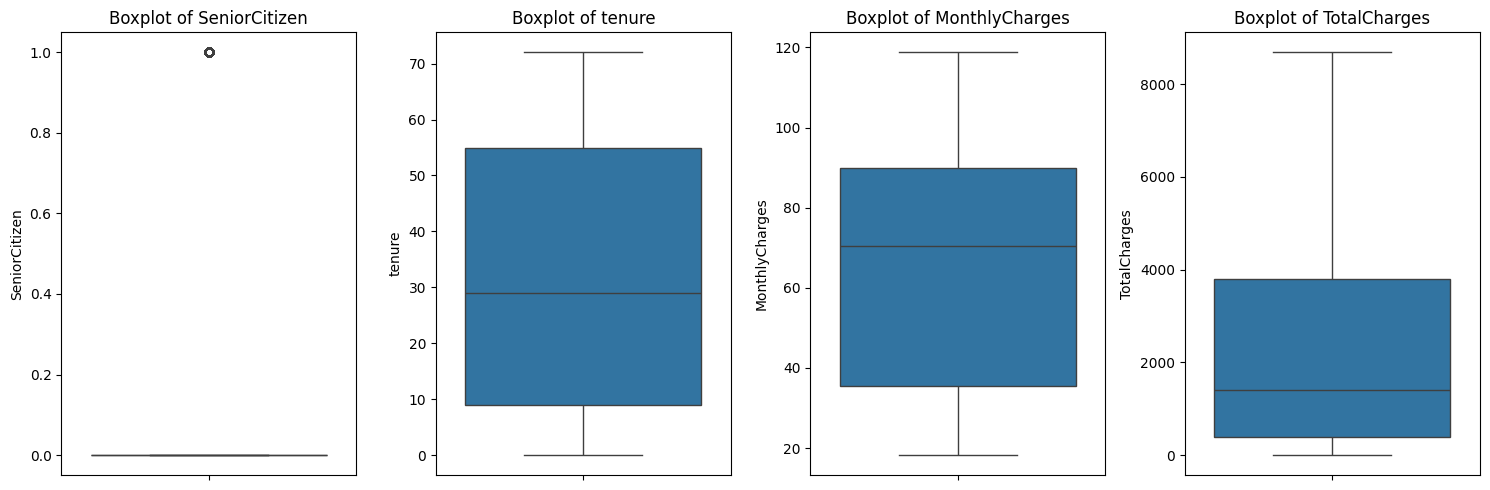


Outlier detection using IQR method:
Column 'SeniorCitizen': 1142 outliers detected.
Column 'tenure': No outliers detected using IQR.
Column 'MonthlyCharges': No outliers detected using IQR.
Column 'TotalCharges': No outliers detected using IQR.


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns to check for outliers:", numeric_cols.tolist())

plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# i will use iqr for outlier detection
print("\nOutlier detection using IQR method:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers detected.")
    else:
        print(f"Column '{col}': No outliers detected using IQR.")

## 5. Exploratory Data Analysis

### Target Variable Distribution

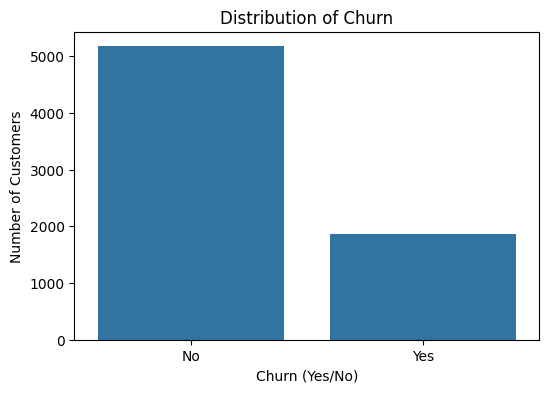

Churn Distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn Percentage: 26.54%
No Churn Percentage: 73.46%


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn')
plt.xlabel('Churn (Yes/No)')
plt.ylabel('Number of Customers')
plt.show()

churn_counts = df['Churn'].value_counts()
print("Churn Distribution:\n", churn_counts)
print(f"Churn Percentage: {churn_counts['Yes'] / len(df) * 100:.2f}%")
print(f"No Churn Percentage: {churn_counts['No'] / len(df) * 100:.2f}%")

### Churn by Contract Type

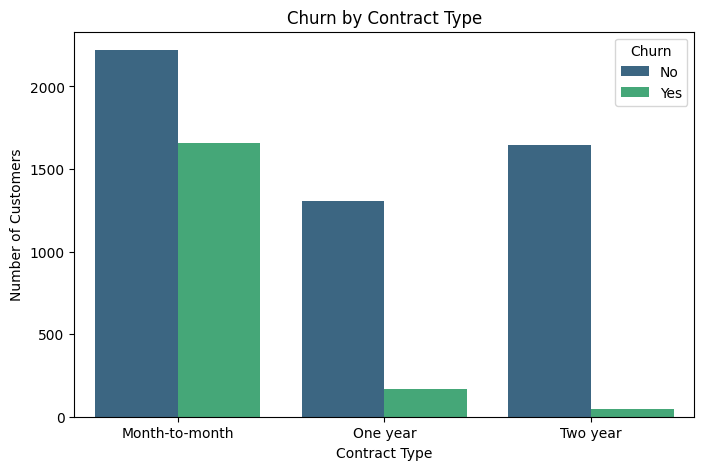

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Churn by Monthly Charges

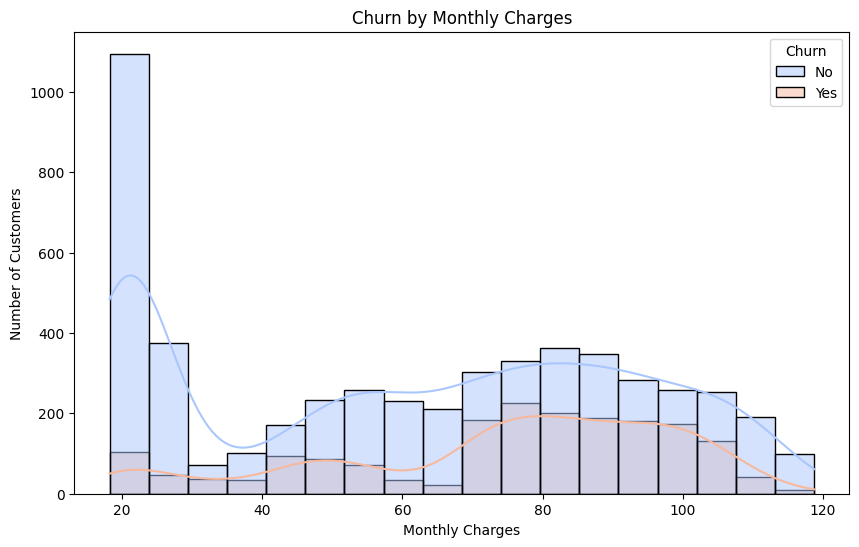

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm')
plt.title('Churn by Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

### Churn by Tenure

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette='viridis')
plt.title('Churn by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### Correlation Heatmap

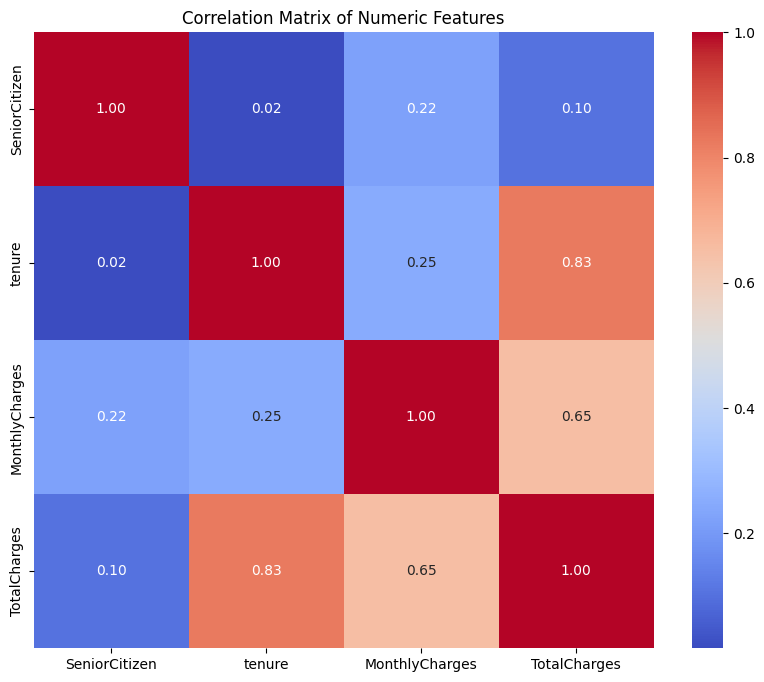

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Numeric Histograms

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Category Countplots

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1) # Adjust subplot grid as needed based on number of categorical columns
    sns.countplot(data=df, x=col, hue='Churn', palette='pastel')
    plt.title(f'Churn by {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

### Encode Categorical Features

In [ ]:

df_processed = df.drop('customerID', axis=1)


X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)


categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline defined for categorical and numerical features.")

### Handle Imbalance

In [ ]:
!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE


X_train_processed = preprocessor.fit_transform(X_train)

feature_names = numerical_features.tolist() + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features))

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

print(f"Shape of X_train before SMOTE: {X_train_processed_df.shape}")
print(f"Shape of y_train before SMOTE: {y_train.shape}")
print(f"Class distribution of y_train before SMOTE:\n{y_train.value_counts()}")

smote = SMOTE(random_state=SEED)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed_df, y_train)

print(f"\nShape of X_train after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train after SMOTE: {y_train_resampled.shape}")
print(f"Class distribution of y_train after SMOTE:\n{y_train_resampled.value_counts()}")

X_test_processed = preprocessor.transform(X_test)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

print("\nData imbalance handled using SMOTE on training data.")

## 7. Model Training


### Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


### Logistic Regression

In [ ]:
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- Training {model_name} ---")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {'model': model, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

model_results = {}

log_reg = LogisticRegression(random_state=SEED)
model_results['Logistic Regression'] = train_and_evaluate_model(log_reg, X_train_resampled, y_train_resampled, X_test_processed_df, y_test, 'Logistic Regression')

### Random Forest

In [ ]:
random_forest = RandomForestClassifier(random_state=SEED)
model_results['Random Forest'] = train_and_evaluate_model(random_forest, X_train_resampled, y_train_resampled, X_test_processed_df, y_test, 'Random Forest')

### XGBoost

In [ ]:
xgb_classifier = XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss') # Suppress warning
model_results['XGBoost'] = train_and_evaluate_model(xgb_classifier, X_train_resampled, y_train_resampled, X_test_processed_df, y_test, 'XGBoost')

### LightGBM

In [ ]:
lgbm_classifier = LGBMClassifier(random_state=SEED)
model_results['LightGBM'] = train_and_evaluate_model(lgbm_classifier, X_train_resampled, y_train_resampled, X_test_processed_df, y_test, 'LightGBM')

### CatBoost

In [ ]:
catboost_classifier = CatBoostClassifier(random_state=SEED, verbose=0) # verbose=0 to suppress output
model_results['CatBoost'] = train_and_evaluate_model(catboost_classifier, X_train_resampled, y_train_resampled, X_test_processed_df, y_test, 'CatBoost')

## 8. Evaluation

### Model Comparison Table

In [ ]:
model_comparison_df = pd.DataFrame(model_results).T
print("\nModel Comparison:\n")
print(model_comparison_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].sort_values(by='roc_auc', ascending=False))

best_model_name = model_comparison_df['roc_auc'].idxmax()
best_model = model_results[best_model_name]['model']
print(f"\nBest performing model based on ROC AUC: {best_model_name}")


Model Comparison:

                     accuracy precision    recall        f1   roc_auc
Logistic Regression  0.738822  0.505085  0.796791  0.618257   0.84028
CatBoost             0.786373   0.59335  0.620321  0.606536  0.836929
LightGBM             0.782825  0.587179  0.612299  0.599476  0.832127
Random Forest        0.772179  0.571429  0.566845  0.569128  0.820504
XGBoost              0.775727  0.575916  0.588235  0.582011  0.819197

Best performing model based on ROC AUC: Logistic Regression


### ROC Curves

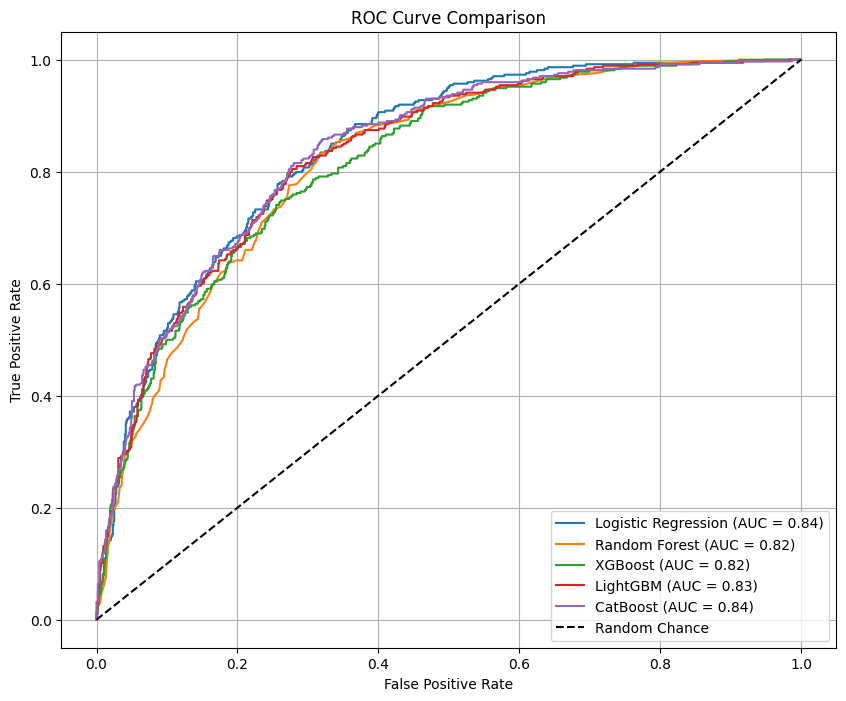

In [ ]:
plt.figure(figsize=(10, 8))

for name, result in model_results.items():
    model = result['model']
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_processed_df)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
    else:
        print(f"Model {name} does not have predict_proba method.")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 9. Hyperparameter Tuning

### Tune Logistic Regression

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': np.logspace(-4, 4, 20),
    'solver': ['liblinear', 'saga']
}


random_search_lr = RandomizedSearchCV(
    LogisticRegression(random_state=SEED, max_iter=1000),
    param_distributions=param_grid_lr,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=SEED
)

print("Starting RandomizedSearchCV for Logistic Regression...")
random_search_lr.fit(X_train_resampled, y_train_resampled)

print("\nBest parameters found:", random_search_lr.best_params_)
print("Best ROC AUC score:", random_search_lr.best_score_)

best_lr_model = random_search_lr.best_estimator_
model_results['Logistic Regression Tuned'] = train_and_evaluate_model(best_lr_model, X_train_resampled, y_train_resampled, X_test_processed_df, y_test, 'Logistic Regression Tuned')

if model_results['Logistic Regression Tuned']['roc_auc'] > model_results[best_model_name]['roc_auc']:
    best_model_name = 'Logistic Regression Tuned'
    best_model = model_results[best_model_name]['model']
    print(f"\nUpdated best performing model based on ROC AUC: {best_model_name}")
else:
    print(f"\nBest performing model remains: {best_model_name}")

## 10. Explainability

### Feature Importance

In [ ]:
print(f"\nFeature Importance for the best model: {best_model_name}")

if hasattr(best_model, 'coef_'):
    feature_importance = pd.DataFrame({'Feature': X_train_resampled.columns, 'Importance': best_model.coef_[0]})
    feature_importance['Importance'] = np.abs(feature_importance['Importance']) # Absolute values for importance
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
    plt.title(f'Top 10 Most Important Features for {best_model_name}')
    plt.show()
    print("\nTop 10 Features and their Importance (absolute coefficient value):\n", feature_importance.head(10))
elif hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({'Feature': X_train_resampled.columns, 'Importance': best_model.feature_importances_})
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
    plt.title(f'Top 10 Most Important Features for {best_model_name}')
    plt.show()
    print("\nTop 10 Features and their Importance:\n", feature_importance.head(10))
else:
    print("Feature importance method not available for this model type.")

### SHAP Values (Top Churn Drivers)

In [ ]:
!pip install shap --quiet
import shap

print(f"\nGenerating SHAP values for {best_model_name}...")

if hasattr(best_model, 'feature_importances_'):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_processed_df)


    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values

    shap.summary_plot(shap_values_to_plot, X_test_processed_df, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance for {best_model_name}')
    plt.show()

    shap.summary_plot(shap_values_to_plot, X_test_processed_df, show=False)
    plt.title(f'SHAP Summary Plot for {best_model_name}')
    plt.show()

    print("SHAP plots generated. These plots visualize the impact of features on model output (churn probability).")


elif hasattr(best_model, 'coef_'):
    explainer = shap.LinearExplainer(best_model, X_train_resampled)
    shap_values = explainer.shap_values(X_test_processed_df)


    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values

    shap.summary_plot(shap_values_to_plot, X_test_processed_df, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance for {best_model_name}')
    plt.show()

    shap.summary_plot(shap_values_to_plot, X_test_processed_df, show=False)
    plt.title(f'SHAP Summary Plot for {best_model_name}')
    plt.show()

    print("SHAP plots generated. These plots visualize the impact of features on model output (churn probability).")

else:
    print("SHAP explainer not yet implemented for this model type.")

## 11. Save Best Model

In [ ]:
import joblib


joblib.dump(best_model, "best_churn_model.pkl")
print(f"Best model ({best_model_name}) saved as best_churn_model.pkl")


joblib.dump(preprocessor, "preprocessor.pkl")
print("Preprocessor saved as preprocessor.pkl")


joblib.dump(feature_names, "feature_names.pkl")
print("Feature names saved as feature_names.pkl")

model_comparison_df.to_csv("model_comparison_results.csv", index=True)
print("Model comparison results saved as model_comparison_results.csv")

Best model (Logistic Regression) saved as best_churn_model.pkl
Preprocessor saved as preprocessor.pkl
Feature names saved as feature_names.pkl
Model comparison results saved as model_comparison_results.csv


## 12. Prediction Demo

In [ ]:
import joblib
import pandas as pd

#i will Load the saved model, preprocessor, and feature names
best_model = joblib.load("best_churn_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")
feature_names = joblib.load("feature_names.pkl")

print("Model, preprocessor, and feature names loaded successfully.")

def make_prediction(customer_data: dict) -> dict:
    """
    Makes a churn prediction for a single customer based on their data.

    Args:
        customer_data (dict): A dictionary containing customer features.

    Returns:
        dict: A dictionary containing the churn probability and predicted label.
    """

    input_df = pd.DataFrame([customer_data])

    original_X_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
                       'MonthlyCharges', 'TotalCharges']

    processed_input_df = pd.DataFrame(columns=original_X_cols)
    for col in original_X_cols:
        if col in input_df.columns:
            processed_input_df[col] = input_df[col]
        else:
            if col in ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']:
                processed_input_df[col] = 0.0
            else:
                processed_input_df[col] = 'No'

    processed_input_df['TotalCharges'] = pd.to_numeric(processed_input_df['TotalCharges'], errors='coerce').fillna(0)

    processed_data = preprocessor.transform(processed_input_df)

    processed_data_df = pd.DataFrame(processed_data, columns=feature_names)

    # Make prediction
    churn_probability = best_model.predict_proba(processed_data_df)[:, 1][0]
    churn_prediction = best_model.predict(processed_data_df)[0]

    return {
        "churn_probability": float(churn_probability),
        "churn_prediction": "Yes" if churn_prediction == 1 else "No"
    }


new_customer_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

print("\nPredicting churn for a new customer:")
prediction_result = make_prediction(new_customer_data)
print(prediction_result)


churn_risk_customer_data = {
    'gender': 'Male',
    'SeniorCitizen': 1,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 5,
    'PhoneService': 'Yes',
    'MultipleLines': 'Yes',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.5,
    'TotalCharges': 477.5
}

print("\nPredicting churn for a high-risk customer:")
churn_risk_prediction = make_prediction(churn_risk_customer_data)
print(churn_risk_prediction)

Model, preprocessor, and feature names loaded successfully.

Predicting churn for a new customer:
{'churn_probability': 0.8592995508047981, 'churn_prediction': 'Yes'}

Predicting churn for a high-risk customer:
{'churn_probability': 0.9338163527038837, 'churn_prediction': 'Yes'}
